1. Import Data

In [ ]:
import pandas as pd
import os

dir_path = '/kaggle/input/datasets/deveshppawar/comsol-data'

rows = []
for root, _, filenames in os.walk(dir_path):
    for file in filenames:
        if file.endswith('.csv') and file.startswith('data_t'):
            print(file)
            t = float(file.split('_t')[1].split('.')[0])
            df = pd.read_csv(os.path.join(root, file), sep=';')
            df_actual = df[7:]
            for i in range(len(df_actual)):
                rows.append(list(map(float, df_actual.iloc[i].values[0].split(","))) + [t])

X = pd.DataFrame(rows, columns=['x', 'y', 'z', 'temp', 't'])

""" add steady state solution with t=100s """
u_steady = pd.read_csv(os.path.join(dir_path, 'data_steady.csv'), sep=';')
u_actual = u_steady[7:]
rows_s = []
for i in range(len(u_actual)):
    rows_s.append(list(map(float, u_actual.iloc[i].values[0].split(","))) + [100.0])
X_s = pd.DataFrame(rows_s, columns=['x', 'y', 'z', 'temp', 't'])

X = pd.concat([X, X_s], ignore_index=True)
X.tail()


data_t1.csv
data_t5.csv
data_t8.csv
data_t3.csv
data_t10.csv
data_t4.csv
data_t7.csv
data_t6.csv
data_t2.csv
data_t9.csv


,x,y,z,temp,t
47141,0.008258,0.013053,0.000000,368.811663,100.0
47142,0.013782,0.017265,0.000000,369.704690,100.0
47143,0.000000,0.027975,0.040996,372.437831,100.0
47144,0.086667,0.000000,0.000000,367.728825,100.0
47145,0.000000,0.011075,0.004278,368.374155,100.0


2. Visualize The Tempearture Plot

<Figure size 1500x500 with 0 Axes>

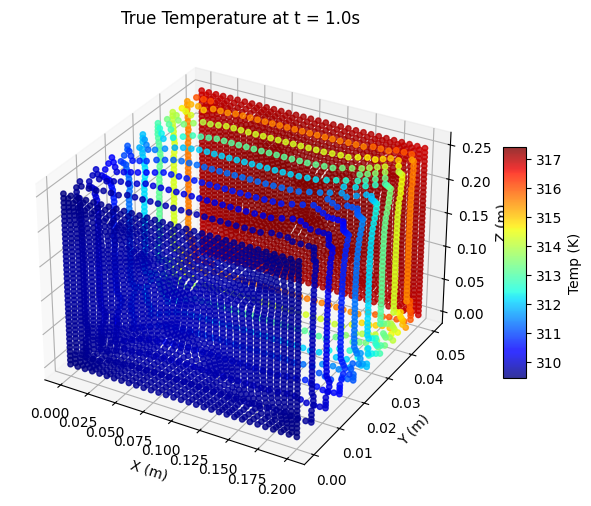

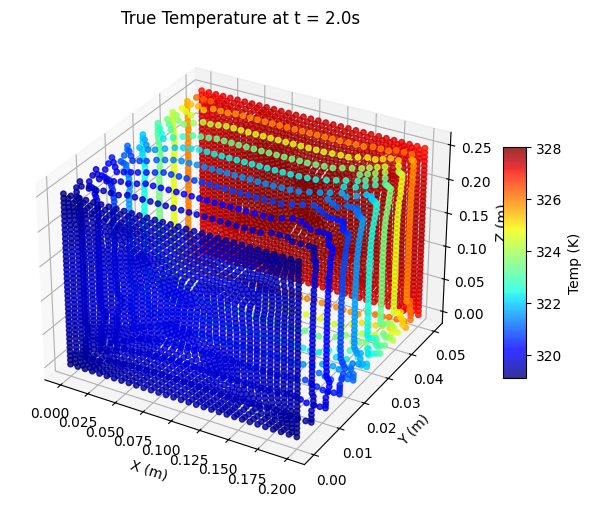

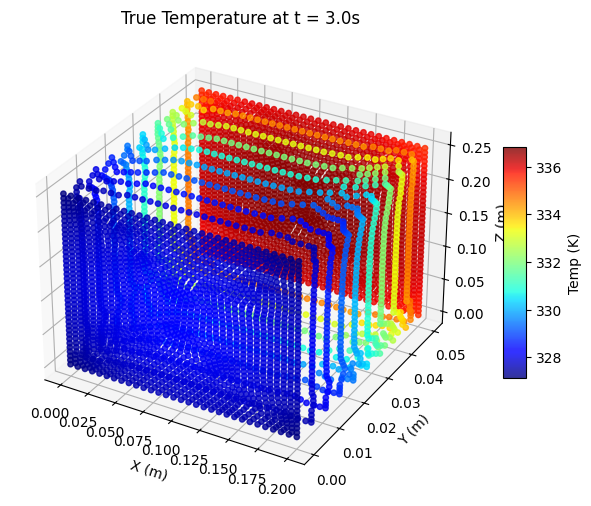

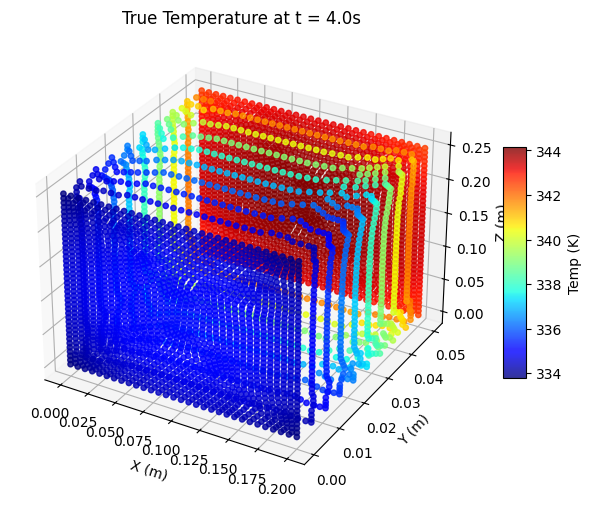

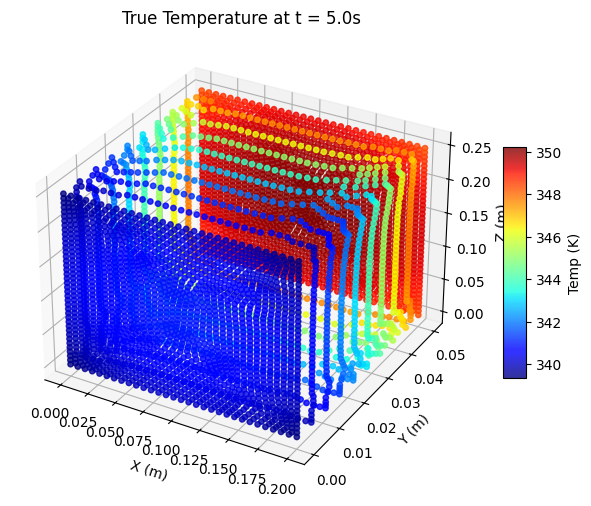

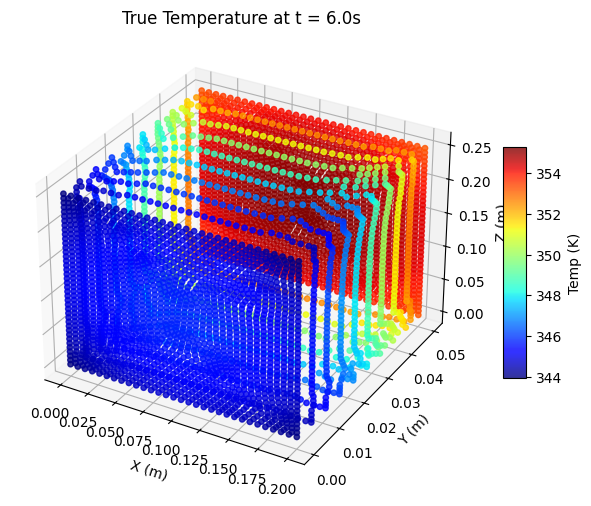

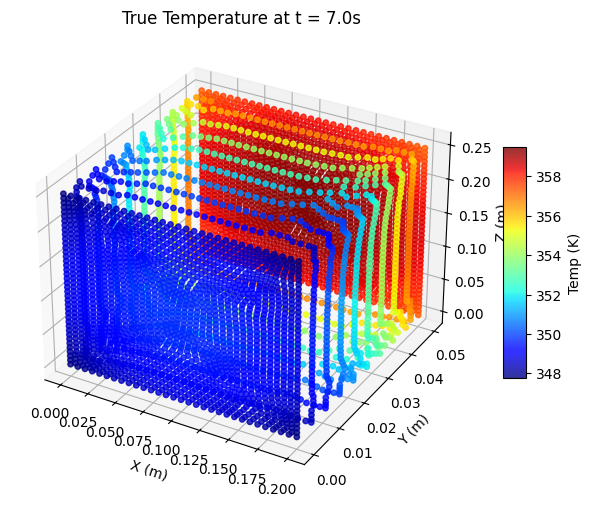

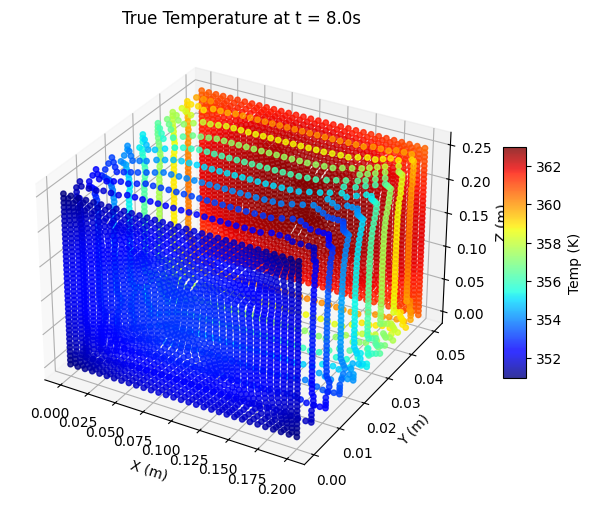

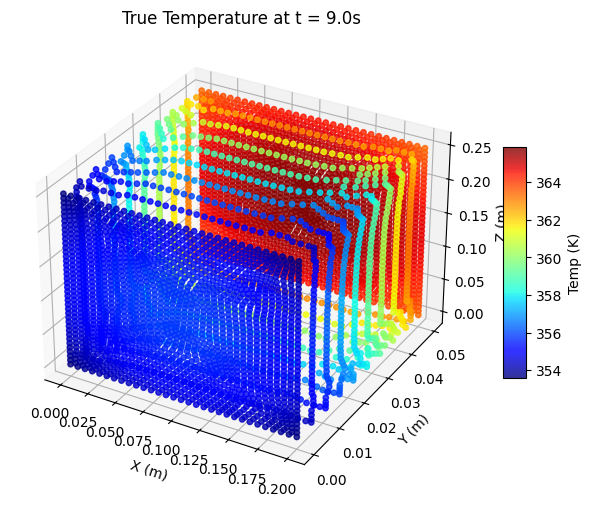

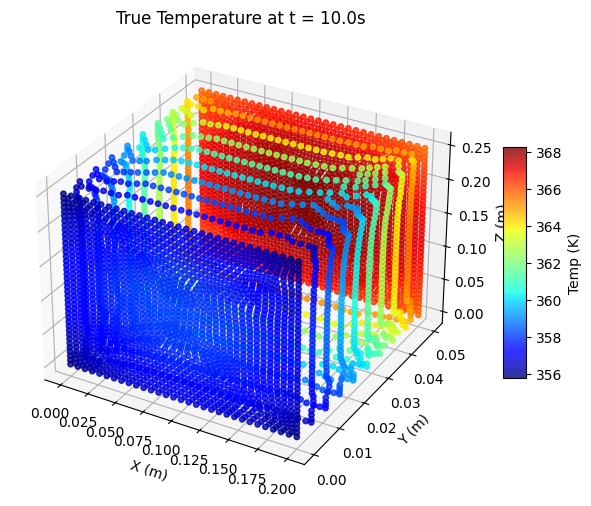

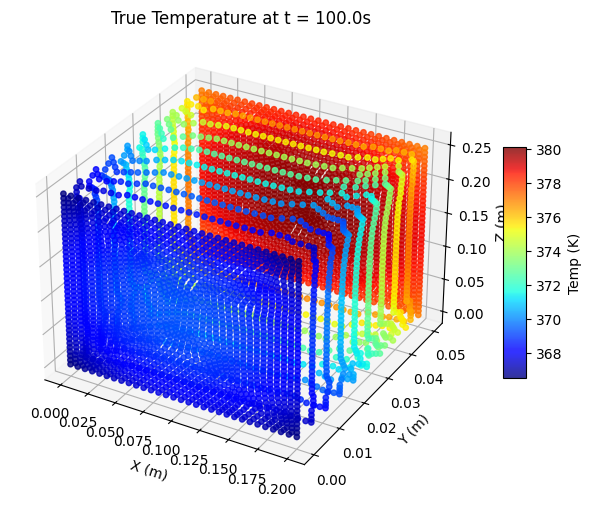

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(15, 5))

def plot_3d_scatter(X, time):
    mask = X["t"] == time
    X_slab = X.loc[mask]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(
        X_slab["x"],
        X_slab["y"],
        X_slab["z"],
        c=X_slab["temp"],
        cmap="jet",
        marker="o",
        s=15,
        alpha=0.8,
    )

    ax.set_title(f"True Temperature at t = {time}s")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, label="Temp (K)")
    plt.show()

times = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 100.0]

for time in times:
    plot_3d_scatter(X, time)
    plt.show()

3. Define Params

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# define params
rho = 15.0
cp = 200.0
h = 15.0
q_flux = 2000.0
T_inf = 300.0
seed = 42
n_sensors = 20


kx = 41. 
ky = 7. 
kz = 41.

# pinn parameters
n_layers = 3
hidden_size = 21
activation = nn.Tanh
lr = 0.001
epochs = 2000
device = 'cuda' if torch.cuda.is_available() else 'cpu'  
print(f'Using device: {device}')

# hyperparams
w_data = 5.0
w_pde = 1.0
w_bc = 5.0
w_ic = 2.0
n_bc = 500
n_pde = 1000


Using device: cuda


4. Create X_train and X_test, and stats

In [ ]:
T_data = X['temp'].values
X_data = X[['x', 'y', 'z', 't']].values
t_unique = np.unique(X.iloc[:, 4])

rng = np.random.RandomState(seed)
xyz = X.iloc[:, :3]
unique_xyz, inverse = np.unique(xyz, axis=0, return_inverse=True)

n_sensors = min(n_sensors, unique_xyz.shape[0])
sensor_loc_idx = rng.choice(unique_xyz.shape[0], size=n_sensors, replace=False)

sensor_mask = np.isin(inverse, sensor_loc_idx)
X_train = X_data[sensor_mask]
T_train = T_data[sensor_mask]

# Split the remaining (non-sensor) points into a VALIDATION and TEST set
rest_idx = np.where(~sensor_mask)[0]
rest_perm = rng.permutation(rest_idx)
n_val = len(rest_perm) // 2

val_idx = rest_perm[:n_val]
test_idx = rest_perm[n_val:]

X_val, T_val = X_data[val_idx], T_data[val_idx]
X_test, T_test = X_data[test_idx], T_data[test_idx]


In [ ]:
X_tr = torch.tensor(X_train, dtype=torch.float32, device=device)
T_tr = torch.tensor(T_train, dtype=torch.float32, device=device).unsqueeze(1)
X_v = torch.tensor(X_val, dtype=torch.float32, device=device)
T_v = torch.tensor(T_val, dtype=torch.float32, device=device).unsqueeze(1)
X_te = torch.tensor(X_test, dtype=torch.float32, device=device)
T_te = torch.tensor(T_test, dtype=torch.float32, device=device).unsqueeze(1)

T_mean = T_tr.mean()
T_std = T_tr.std().clamp(min=1e-6)


Lx, Ly, Lz = 0.2, 0.05, 0.25
t_max_phys = float(X_data[:, 3].max())  # 100 s (steady-state snapshot)

domain_min = torch.tensor([0.0, 0.0, 0.0, 0.0], device=device)
domain_max = torch.tensor([Lx, Ly, Lz, t_max_phys], device=device)

x_min_b, x_max_b = 0.0, Lx
y_min_b, y_max_b = 0.0, Ly
z_min_b, z_max_b = 0.0, Lz
t_min_b, t_max_b = 0.0, t_max_phys


In [6]:
len(X_v)

23463

5. Define PINN Layers and helper functions

In [7]:
# layers
layers = [nn.Linear(4, hidden_size), activation()]
for _ in range(n_layers-1):
    layers += [nn.Linear(hidden_size, hidden_size), activation()]

layers += [nn.Linear(hidden_size, 1)]
network = nn.Sequential(*layers).to(device)


In [8]:
def normalize(X):
    # Maps the known physical domain -> [-1, 1]. Differentiable (affine),
    # so autograd correctly propagates through it in the PDE/BC losses.
    return 2.0 * (X - domain_min) / (domain_max - domain_min) - 1.0

def forward(X_norm):
    return network(X_norm)

def predict(X_phys):
    X_norm = normalize(X_phys)
    T_norm = forward(X_norm)
    return T_norm*T_std + T_mean 


6. Define physics Loss

In [ ]:
def pde_loss(X_phys):
    X_phys = X_phys.requires_grad_(True)
    X_n = normalize(X_phys)
    T_n = forward(X_n)
    T_phys = T_n * T_std + T_mean

    grad1 = torch.autograd.grad(T_phys, X_phys, grad_outputs=torch.ones_like(T_phys), create_graph=True)[0]
    dTdx, dTdy, dTdz, dTdt = grad1[:, 0:1], grad1[:, 1:2], grad1[:, 2:3], grad1[:, 3:4]

    d2Tdx2 = torch.autograd.grad(dTdx, X_phys, torch.ones_like(dTdx), create_graph=True)[0][:, 0:1]
    d2Tdy2 = torch.autograd.grad(dTdy, X_phys, torch.ones_like(dTdy), create_graph=True)[0][:, 1:2]
    d2Tdz2 = torch.autograd.grad(dTdz, X_phys, torch.ones_like(dTdz), create_graph=True)[0][:, 2:3]

    residual = (kx * d2Tdx2 + ky * d2Tdy2 + kz * d2Tdz2 - rho * cp * dTdt)
    return torch.mean(residual**2)

def bc_physics_loss(bc_type, X_bc_phys, face_axis, face_sign):
    k_vals = [kx, ky, kz]
    k_n = k_vals[face_axis]

    X_bc = X_bc_phys.requires_grad_(True)

    T_bc = predict(X_bc)

    grad1 = torch.autograd.grad(
        T_bc, X_bc, torch.ones_like(T_bc), create_graph=True
    )[0]
    dT_dn = grad1[:, face_axis:face_axis + 1]

    if bc_type == 'convection':
        residual = face_sign * k_n * dT_dn - h * (T_bc - T_inf)
    elif bc_type == 'neumann_flux':
        residual = face_sign * k_n * dT_dn + q_flux
    else:
        raise ValueError(f'Unknown boundary condition: {bc_type}')

    return torch.mean(residual**2)

def ic_physics_loss(X_ic_physics):
    # The initial temperature across all X_ic_physics is 300 K
    T_ic = predict(X_ic_physics)
    residual = T_ic - torch.full_like(T_ic, 300.0)
    return torch.mean(residual**2)


7. Train the model

In [10]:
# optimizer and schedular

opt = torch.optim.Adam(network.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, patience=200, factor=0.5, min_lr=1e-6
)

In [ ]:

X_tr_n = normalize(X_tr)
X_v_n = normalize(X_v)
T_tr_n = (T_tr - T_mean) / T_std
T_v_n = (T_v - T_mean) / T_std

def _sample_pde():
    xs1 = torch.rand(n_pde, 4, device=device)
    xs1[:, 0] = xs1[:, 0] * (x_max_b - x_min_b) + x_min_b
    xs1[:, 1] = xs1[:, 1] * (y_max_b - y_min_b) + y_min_b
    xs1[:, 2] = xs1[:, 2] * (z_max_b - z_min_b) + z_min_b
    xs1[:, 3] = xs1[:, 3] * (t_max_b - t_min_b) + t_min_b
    return xs1

def _sample_bc(axis, coord):
    xs2 = torch.rand(n_bc, 4, device=device)
    xs2[:, 0] = xs2[:, 0] * (x_max_b - x_min_b) + x_min_b
    xs2[:, 1] = xs2[:, 1] * (y_max_b - y_min_b) + y_min_b
    xs2[:, 2] = xs2[:, 2] * (z_max_b - z_min_b) + z_min_b
    xs2[:, 3] = xs2[:, 3] * (t_max_b - t_min_b) + t_min_b
    xs2[:, axis] = coord
    return xs2

def _sample_ic():
    xs3 = torch.rand(n_pde, 4, device=device)
    xs3[:, 0] = xs3[:, 0] * (x_max_b - x_min_b) + x_min_b
    xs3[:, 1] = xs3[:, 1] * (y_max_b - y_min_b) + y_min_b
    xs3[:, 2] = xs3[:, 2] * (z_max_b - z_min_b) + z_min_b
    xs3[:, 3] = 0.0
    return xs3


In [ ]:
import copy
bc_specs = [
    ('neumann_flux', 1, y_max_b, -1.0),
    ('convection', 1, y_min_b, 1.0),
    ('convection', 0, x_min_b, 1.0),
    ('convection', 0, x_max_b, -1.0),
    ('convection', 2, z_min_b, 1.0),
    ('convection', 2, z_max_b, -1.0),
]

history = {'train': [], 'validation': [], 'data': [], 'pde': [], 'bc': [], 'ic': []}
best_val_mae = float('inf')
best_val_mse = float('inf')
best_epoch = 0
best_state = copy.deepcopy(network.state_dict())
epochs_no_improve = 0
early_stopping_patience = 500

# --- Loss scale normalization -------------------------------------------
# capture each term's own magnitude once at the start of training
# (before any weights update anything) and divide by it every epoch, so
# w_data/w_pde/w_bc/w_ic control RELATIVE importance as intended.
network.eval()
with torch.no_grad():
    scale_data = F.mse_loss(forward(X_tr_n), T_tr_n).item() + 1e-8
network.train()
scale_pde = pde_loss(_sample_pde()).item() + 1e-8
scale_bc = torch.stack([
    bc_physics_loss(bc_type, _sample_bc(axis, coord), axis, face_sign)
    for bc_type, axis, coord, face_sign in bc_specs
]).mean().item() + 1e-8
scale_ic = ic_physics_loss(_sample_ic()).item() + 1e-8

print(
    f'Initial loss scales -> data: {scale_data:.3e} | pde: {scale_pde:.3e} | '
    f'bc: {scale_bc:.3e} | ic: {scale_ic:.3e}'
)

for epoch in range(1, epochs + 1):
    network.train()
    opt.zero_grad()

    predicted_train = forward(X_tr_n)
    loss_data = F.mse_loss(predicted_train, T_tr_n)
    loss_pde = pde_loss(_sample_pde())
    loss_bc = torch.stack([
        bc_physics_loss(bc_type, _sample_bc(axis, coord), axis, face_sign)
        for bc_type, axis, coord, face_sign in bc_specs
    ]).mean()
    loss_ic = ic_physics_loss(_sample_ic())

    loss = (
        w_data * (loss_data / scale_data)
        + w_pde * (loss_pde / scale_pde)
        + w_bc  * (loss_bc  / scale_bc)
        + w_ic  * (loss_ic  / scale_ic)
    )
    loss.backward()
    opt.step()

    network.eval()
    with torch.no_grad():
        # Normalized T-space; fine for early stopping / scheduler since
        # it's scale-invariant. Physical-unit (K) metrics come at the end.
        val_prediction = forward(X_v_n)
        val_mse = F.mse_loss(val_prediction, T_v_n)
        val_mae = F.l1_loss(val_prediction, T_v_n)

    scheduler.step(val_mse.detach())
    history['train'].append(loss.item())
    history['validation'].append(val_mse.item())
    history['data'].append(loss_data.item())
    history['pde'].append(loss_pde.item())
    history['bc'].append(loss_bc.item())
    history['ic'].append(loss_ic.item())

    if epoch % 10 == 0 or epoch == 1:
        print(
            f'Epoch {epoch}/{epochs} | '
            f'train: {loss.item():.6e} | val (norm): {val_mse.item():.6e} | '
            f'data: {loss_data.item():.6e} | pde: {loss_pde.item():.6e} | '
            f'bc: {loss_bc.item():.6e} | ic: {loss_ic.item():.6e}'
        )

    current_val_mae = val_mae.item()
    current_val_mse = val_mse.item()
    if current_val_mae < best_val_mae:
        best_val_mae = current_val_mae
        best_val_mse = current_val_mse
        best_epoch = epoch
        best_state = copy.deepcopy(network.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stopping_patience:
        print(f'Early stopping at epoch {epoch}.')
        break

network.load_state_dict(best_state)
network.eval()
model = network

with torch.no_grad():
    final_val_prediction = predict(X_v)
    final_val_mse = F.mse_loss(final_val_prediction, T_v).item()
    final_val_mae = F.l1_loss(final_val_prediction, T_v).item()

    final_test_prediction = predict(X_te)
    final_test_mse = F.mse_loss(final_test_prediction, T_te).item()
    final_test_mae = F.l1_loss(final_test_prediction, T_te).item()

print(
    f'Best epoch: {best_epoch} | '
    f'validation MSE: {final_val_mse:.4f} K^2 | validation MAE: {final_val_mae:.4f} K'
)
print(
    f'Test MSE: {final_test_mse:.4f} K^2 | Test MAE: {final_test_mae:.4f} K'
)


Initial loss scales -> data: 1.056e+00 | pde: 1.850e+07 | bc: 1.399e+06 | ic: 2.443e+03
Epoch 1/2000 | train: 1.294750e+01 | val (norm): 1.034798e+00 | data: 1.056015e+00 | pde: 1.787069e+07 | bc: 1.392442e+06 | ic: 2.448149e+03
Epoch 10/2000 | train: 1.040300e+01 | val (norm): 9.627512e-01 | data: 9.719651e-01 | pde: 8.501304e+06 | bc: 9.724136e+05 | ic: 2.278718e+03
Epoch 20/2000 | train: 9.696955e+00 | val (norm): 9.369689e-01 | data: 9.383320e-01 | pde: 7.767346e+06 | bc: 8.620070e+05 | ic: 2.141348e+03
Epoch 30/2000 | train: 9.204545e+00 | val (norm): 9.197417e-01 | data: 9.205344e-01 | pde: 6.182502e+06 | bc: 7.956489e+05 | ic: 2.037173e+03
Epoch 40/2000 | train: 8.657179e+00 | val (norm): 9.076086e-01 | data: 9.083274e-01 | pde: 4.250980e+06 | bc: 7.117254e+05 | ic: 1.933123e+03
Epoch 50/2000 | train: 8.200598e+00 | val (norm): 8.990862e-01 | data: 8.996196e-01 | pde: 4.915606e+06 | bc: 6.048529e+05 | ic: 1.848557e+03
Epoch 60/2000 | train: 7.809544e+00 | val (norm): 8.910466e-0

8. Plot the results

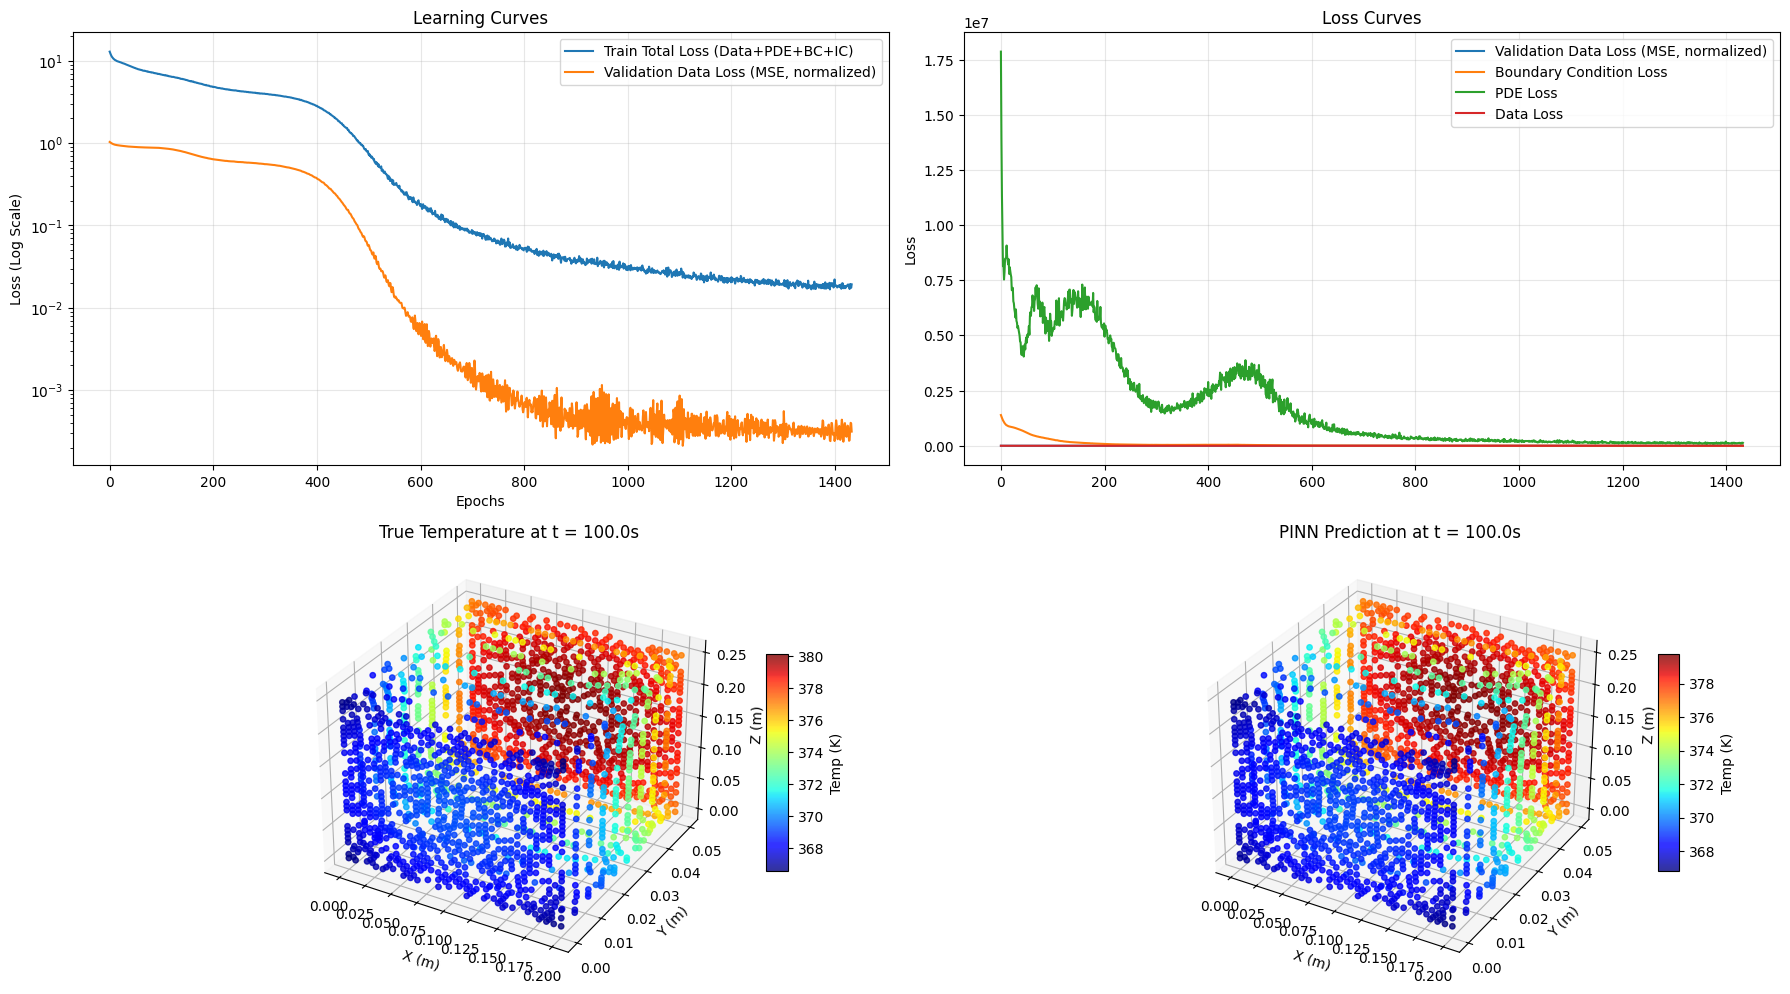

In [13]:
fig = plt.figure(figsize=(18, 10))

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(history['train'], label='Train Total Loss (Data+PDE+BC+IC)')
ax1.plot(history['validation'], label='Validation Data Loss (MSE, normalized)')
ax1.set_yscale('log')
ax1.set_title('Learning Curves')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Log Scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(history['validation'], label='Validation Data Loss (MSE, normalized)')
ax2.plot(history['bc'], label='Boundary Condition Loss')
ax2.plot(history['pde'], label='PDE Loss')
ax2.plot(history['data'], label='Data Loss')
ax2.set_title('Loss Curves')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# final_val_prediction is now in physical units (K) via predict(), so it's
# directly comparable to T_true_slab -- no extra denormalization needed here.
t_max = np.max(X_val[:, 3])
mask = (X_val[:, 3] == t_max)
X_slab = X_val[mask]
T_true_slab = T_val[mask]
T_pred_slab = final_val_prediction[mask].detach().cpu().numpy().flatten()

ax3 = fig.add_subplot(2, 2, 3, projection='3d')
sc1 = ax3.scatter(X_slab[:, 0], X_slab[:, 1], X_slab[:, 2],
                    c=T_true_slab, cmap='jet', marker='o', s=15, alpha=0.8)
ax3.set_title(f'True Temperature at t = {t_max}s')
ax3.set_xlabel('X (m)')
ax3.set_ylabel('Y (m)')
ax3.set_zlabel('Z (m)')
fig.colorbar(sc1, ax=ax3, shrink=0.5, aspect=10, label='Temp (K)')

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
sc2 = ax4.scatter(X_slab[:, 0], X_slab[:, 1], X_slab[:, 2],
                    c=T_pred_slab, cmap='jet', marker='o', s=15, alpha=0.8)
ax4.set_title(f'PINN Prediction at t = {t_max}s')
ax4.set_xlabel('X (m)')
ax4.set_ylabel('Y (m)')
ax4.set_zlabel('Z (m)')
fig.colorbar(sc2, ax=ax4, shrink=0.5, aspect=10, label='Temp (K)')

plt.tight_layout()
plt.show()


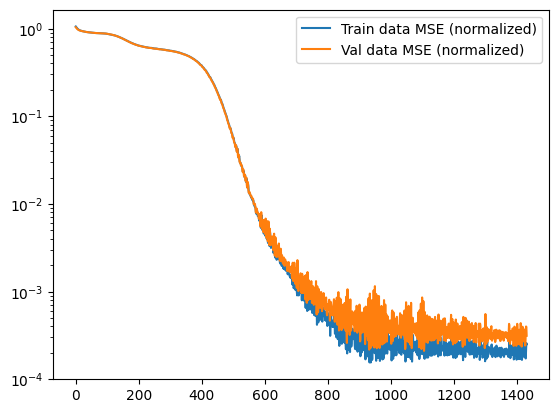

In [14]:
plt.plot(history['data'], label='Train data MSE (normalized)')
plt.plot(history['validation'], label='Val data MSE (normalized)')
plt.yscale('log')
plt.legend()